<a href="https://colab.research.google.com/github/MamoMGD1/ISE302-DataMining-GroupProject/blob/main/students/models/model_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model 4 — Fast Car Classifier (Naive Bayes)

## Research Question
Based on a car's body type, fuel type, drivetrain, and transmission — can we predict whether it is a fast car (0–100 km/h under 11.5 seconds)?

## Introduction
This notebook applies **Gaussian Naive Bayes** to classify cars as "fast" or "slow" based on categorical and encoded features.

**Rules for this notebook:**
- Uses **unscaled data** (`proceed_dataset_without_scaling.csv`)
- You **must use `GaussianNB`** — no other algorithm is acceptable
- You **must create the `hızlı_araba` binary column** before training (see Feature Engineering)
- **Note:** Naive Bayes assumes feature independence — this is an approximation that should be acknowledged in your analysis
- You **may choose different features**, add features, and tune hyperparameters — but you **cannot change the general technique category** (must remain Naive Bayes)

## Data Import
Loads all required libraries and reads the unscaled dataset directly from GitHub. The dataset is printed with its shape so you can verify it loaded correctly.

In [393]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv('https://raw.githubusercontent.com/MamoMGD1/ISE302-DataMining-GroupProject/main/data/proceed_dataset_without_scaling.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (2589, 87)


,Fiyat,Yıl,Kilometre,İlan Tarihi,Ortalama Kasko,Ortalama Trafik Sigortası,Üretim Yılı (İlk/Son),Silindir Sayısı,Koltuk Sayısı,Bagaj Hacmi,...,Hızlanma (0-100),Maksimum Hız,Uzunluk,Genişlik,Yükseklik,Ağırlık,Boş Ağırlığı,Aks Aralığı,Jant Boyutu,log_Fiyat
0,2425000,2025,6001,0.507585,9.730597,9.436162,2024.524726,3,5,6.255935,...,10.1,198.0,8.388223,1806.0,1590.0,7.530480,1315.0,7.881182,17,14.701342
1,2900000,2025,16000,0.540567,9.801196,9.426602,2024.561718,4,5,6.312241,...,9.2,199.0,8.395252,1848.0,1625.0,7.591862,1450.0,7.888335,19,14.880222
2,1150000,2015,265000,0.437396,9.847922,9.310729,2015.500000,4,5,5.996452,...,12.4,180.0,8.384804,1800.0,1590.0,7.555382,1365.0,7.881182,19,13.955273
3,1240000,2014,196000,0.403619,9.796904,9.310729,2015.500000,4,5,5.996452,...,10.7,182.0,8.384804,1800.0,1590.0,7.603898,1461.0,7.881182,17,14.030623
4,690000,2011,305000,0.354720,9.696057,9.341037,2011.476979,4,5,6.115519,...,12.2,174.0,8.370084,1780.0,1615.0,7.565793,1407.0,7.875119,16,13.444448


##Feature Engineering
Creates the binary target column `hızlı_araba` based on the `Hızlanma (0-100)` column:

1 = fast car (0–100 km/h in under 11.5 seconds)
0 = slow car (11.5 seconds or more)

The `Hızlanma (0-100)` column is not included in the feature set in the next step to avoid data leakage — the model would otherwise be directly predicting from the value it's trying to classify.

In [394]:
# Create binary target: 1 = fast car (0-100 km/h in under 9 seconds), 0 = slow car
# We drop 'Hızlanma (0-100)' from features after creating the target to avoid data leakage
df['hızlı_araba'] = (df['Hızlanma (0-100)'] < 11.5).astype(int)
print(f"Fast cars: {df['hızlı_araba'].sum()} ({df['hızlı_araba'].mean()*100:.1f}%)")
print(f"Slow cars: {(df['hızlı_araba'] == 0).sum()} ({(df['hızlı_araba'] == 0).mean()*100:.1f}%)")

Fast cars: 1292 (49.9%)
Slow cars: 1297 (50.1%)


## Feature Selection

Starting with a broad list of candidate features — including engine power, engine displacement, torque, transmission type, body type, drivetrain, fuel type, weight, and more — we let the model tell us which ones actually matter.

Missing values are filled with 0 and the data is split **80/20** into training and test sets, with **stratification** to preserve the fast/slow class ratio in both splits.

We then use **SequentialFeatureSelector** from scikit-learn, which tests feature combinations one by one and keeps only the ones that improve accuracy. This removes the guesswork — instead of manually picking features, we let the selector find the best subset automatically.

> The commented-out code below shows the full selection process. The final chosen features are used in upcoming cells.

In [395]:
# recommended_features = [
#     'Yıl',
#     'Kilometre',
#     'İlan Tarihi',
#     'Ortalama Kasko',
#     'Ortalama Trafik Sigortası',
#     'Üretim Yılı (İlk/Son)',
#     'Silindir Sayısı',
#     'Koltuk Sayısı',
#     'Bagaj Hacmi',
#     'Yakıt Deposu',
#     'Seri',
#     'Model',
#     'Vites Tipi',
#     'Sınıfı',
#     'is_Nissan',
#     'Yakıt Tipi_Dizel',
#     'Yakıt Tipi_Elektrik',
#     'Yakıt Tipi_Hibrit',
#     'Yakıt Tipi_LPG & Benzin',
#     'Kasa Tipi_Coupe',
#     'Kasa Tipi_Crossover',
#     'Kasa Tipi_Hard top',
#     'Kasa Tipi_Panelvan',
#     'Kasa Tipi_Pick-Up',
#     'Kasa Tipi_SUV',
#     'Çekiş_AWD (Elektronik)',
#     'Çekiş_Arkadan İtiş',
#     'Çekiş_Önden Çekiş',
#     'total_changed_parts',
#     'is_fully_original',
#     'Motor Hacmi',
#     'Motor Gücü',
#     'Ort. Yakıt Tüketimi',
#     'Tork',
#     'Maksimum Güç',
#     'Minimum Güç',
#     'Maksimum Hız',
#     'Uzunluk',
#     'Genişlik',
#     'Yükseklik',
#     'Ağırlık',
#     'Boş Ağırlığı',
#     'Aks Aralığı',
#     'Jant Boyutu',
# ]
# features = [f for f in recommended_features if f in df.columns]
# target = 'hızlı_araba'

# X = df[features].fillna(0)
# y = df[target]

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)
# print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
# print(f"Class balance in train: {y_train.value_counts().to_dict()}")

## Feature Selection using Sklearn

To avoid guessing which features matter, we use **SequentialFeatureSelector** from Sklearn.
It tests feature combinations and picks the ones that contribute the most to model accuracy.

The selector works by adding features one by one (forward selection), evaluating each combination
using cross-validation, and keeping only the ones that improve the score.

> **Note:** After running the cell below, only use the **top 4-6 features** in your final model.
> Using too many features can cause overfitting — the model memorizes the training data instead of learning patterns.
> You can also experiment with `n_features_to_select` to see how the number of features affects accuracy.



In [396]:
# from sklearn.feature_selection import SequentialFeatureSelector
# from sklearn.naive_bayes import GaussianNB

# # 1. Initialize the model
# gnb = GaussianNB()

# # 2. Initialize the Selector
# # 'n_features_to_select' can be an integer or "auto"
# # 'direction' can be 'forward' or 'backward'
# sfs = SequentialFeatureSelector(
#     gnb,
#     n_features_to_select=10,  # Let's find the top 10 best features
#     direction='forward',
#     scoring='accuracy',
#     cv=5,
#     n_jobs=-1 # Uses all your CPU cores to speed it up
# )

# print("Starting feature selection... (this may take a minute)")
# sfs.fit(X_train, y_train)

# # 3. Get the names of the features that were chosen
# best_features = X_train.columns[sfs.get_support()].tolist()

# print("-" * 30)
# print(f"Best 10 features identified:")
# for i, feat in enumerate(best_features, 1):
#     print(f"{i}. {feat}")

# # 4. Evaluate the model with ONLY those features
# X_train_best = sfs.transform(X_train)
# X_test_best = sfs.transform(X_test)

# gnb.fit(X_train_best, y_train)
# final_accuracy = gnb.score(X_test_best, y_test)

# print("-" * 30)
# print(f"Final Accuracy with top features: {final_accuracy:.4f}")



## Feature Selection Conclusion

After running the Sequential Feature Selector, the combination that gave us the best accuracy was these 4 features:

1. Ortalama Trafik Sigortası
2. Motor Hacmi
3. Motor Gücü
4. Genişlik

Interestingly, **Trafik Sigortası (Traffic Insurance)** was picked by the selector even though it has no direct relationship with speed. This is because insurance premiums correlate with vehicle performance profiles — powerful and fast cars are statistically riskier, so they cost more to insure. The feature acts as an indirect proxy for engine power and car type.

> **However**, we chose to experiment with our own set of features instead to see how the model performs with more directly relevant inputs. Feel free to swap in the 4 features above to compare results and probably you will get a better F1 score and accuracy.


In [397]:
recommended_features = [
    'Vites Tipi',
    'Motor Hacmi',
    'Motor Gücü',
    'Tork',
    'Kasa Tipi_Coupe',
]
features = [f for f in recommended_features if f in df.columns]
target = 'hızlı_araba'

X = df[features].fillna(0)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Class balance in train: {y_train.value_counts().to_dict()}")

Training set: (2071, 5), Test set: (518, 5)
Class balance in train: {0: 1037, 1: 1034}


##Model Training
Trains a `GaussianNB` classifier with `var_smoothing=1e-9`. This smoothing parameter controls how much variance is added to each feature's distribution to stabilize likelihood estimates — higher values make the model less sensitive to rare feature values.
After fitting, the model generates both hard predictions `(y_pred)` and probability scores `(y_prob)` on the test set. The probability scores reflect the model's confidence that each car is a fast car.

In [398]:
from sklearn.naive_bayes import GaussianNB

# GaussianNB has minimal hyperparameters you may experiment with var_smoothing
model = GaussianNB(var_smoothing=1e-9)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probability of being a fast car
print("Naive Bayes model trained.")

Naive Bayes model trained.


##Evaluation
###Classification Report
Prints `precision`, `recall`, `F1-score`, and `support` for both classes `(Slow / Fast)` using the actual test set predictions from your trained model.

In [399]:
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Slow (0)', 'Fast (1)']))

=== Classification Report ===
              precision    recall  f1-score   support

    Slow (0)       0.82      0.82      0.82       260
    Fast (1)       0.82      0.82      0.82       258

    accuracy                           0.82       518
   macro avg       0.82      0.82      0.82       518
weighted avg       0.82      0.82      0.82       518



##Confusion Matrix
Visualizes prediction outcomes as a heatmap. Each cell shows the count of predictions in that true-label / predicted-label combination. Correct predictions fall on the diagonal; off-diagonal cells represent misclassifications.

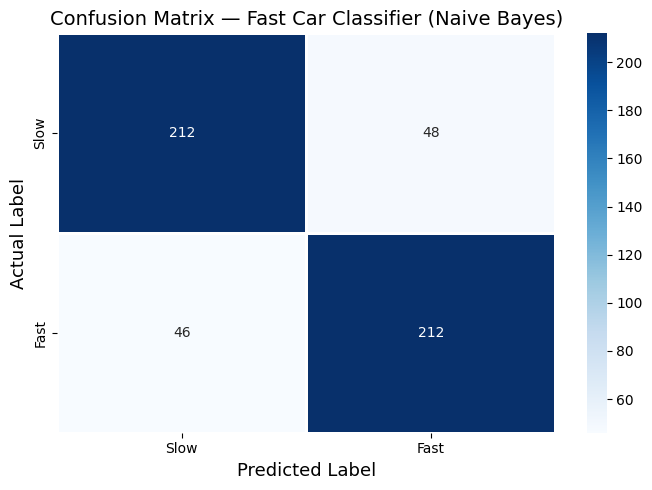

In [400]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Slow', 'Fast'], yticklabels=['Slow', 'Fast'],
            linewidths=1, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_ylabel('Actual Label', fontsize=13)
ax.set_title('Confusion Matrix — Fast Car Classifier (Naive Bayes)', fontsize=14)
plt.tight_layout()
plt.show()

## Understanding Confidence %

Before looking at the results, it is important to understand what the **Confidence** column means.

The model does not just say *fast* or *slow* — it returns a probability score for each class.
For example: `[0.3, 0.7]` means 30% chance SLOW, 70% chance FAST.

The model then needs to make a final decision using a cutoff point:

- **Confidence > 50%** → FAST is more probable → predict FAST
- **Confidence < 50%** → SLOW is more probable → predict SLOW
- **Confidence = 50%** → complete uncertainty


## DEMO 1 — Real Cars from Dataset
Randomly picks 10 real cars from the dataset and runs them through the trained Naive Bayes model.
The **Actual** column shows the true label based on the real 0-100 time, while **Predicted**
shows what the model guessed using only the 5 selected features. **Correct?** tells you if they match.

Note: Random state is not used which means that everytime you run this the results are going to be different

In [401]:
# DEMO: Predict on Real Cars from the Dataset
from IPython.display import display

sample = df[features + ['Hızlanma (0-100)', 'hızlı_araba']].dropna().sample(10)

probs = model.predict_proba(sample[features])[:, 1]
preds = model.predict(sample[features])

results = pd.DataFrame({
    '0-100'    : sample['Hızlanma (0-100)'].values,
    'Vites Tipi'   : sample['Vites Tipi'].values,
    'Motor Hacmi'  : sample['Motor Hacmi'].values,
    'Motor Gücü'   : sample['Motor Gücü'].values,
    'Tork'         : sample['Tork'].values,
    'Is Coupe'     : sample['Kasa Tipi_Coupe'].values,
    'Confidence' : [f"{p*100:.1f}%" for p in probs],
    'Predicted'  : ['FAST' if p == 1 else 'SLOW' for p in preds],
    'Actual'     : ['FAST' if a == 1 else 'SLOW' for a in sample['hızlı_araba']],
    'Correct?'   : ['Correct' if p == a else 'False' for p, a in zip(preds, sample['hızlı_araba'])]
})

display(results.reset_index(drop=True))



,0-100,Vites Tipi,Motor Hacmi,Motor Gücü,Tork,Is Coupe,Confidence,Predicted,Actual,Correct?
0,11.1,2,1591.0,4.912655,165.0,0.0,48.8%,SLOW,FAST,False
1,11.2,0,1461.0,4.709530,260.0,0.0,12.3%,SLOW,FAST,False
2,12.7,0,2250.5,5.099866,356.0,0.0,29.7%,SLOW,SLOW,Correct
3,11.1,0,1591.0,4.912655,165.0,0.0,24.2%,SLOW,FAST,False
4,11.1,2,1598.0,4.875197,320.0,0.0,79.5%,FAST,FAST,Correct
5,13.7,2,1368.0,4.615121,134.0,0.0,3.6%,SLOW,SLOW,Correct
6,11.3,0,1461.0,4.709530,240.0,0.0,10.0%,SLOW,FAST,False
7,10.1,1,1332.0,5.081404,270.0,0.0,92.1%,FAST,FAST,Correct
8,11.3,0,1461.0,4.709530,240.0,0.0,10.0%,SLOW,FAST,False
9,10.1,2,1300.5,5.099866,270.0,0.0,94.9%,FAST,FAST,Correct


## DEMO 1: Visualization

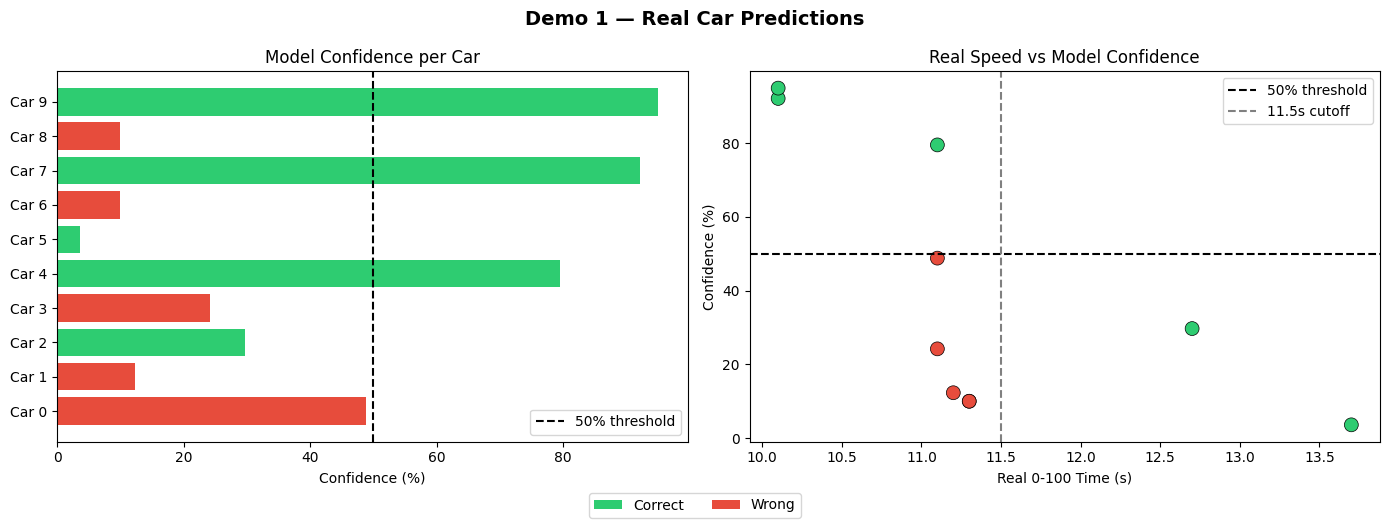

In [402]:
# DEMO 1: Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

conf_vals = [float(p.strip('%')) for p in results['Confidence']]
accel_vals = sample['Hızlanma (0-100)'].values
correct = results['Correct?'].values
colors = ['#2ecc71' if 'Correct' in str(c) else '#e74c3c' for c in correct]

# Bar chart: Confidence per car
axes[0].barh(range(len(results)), conf_vals, color=colors)
axes[0].axvline(x=50, color='black', linestyle='--', linewidth=1.5, label='50% threshold')
axes[0].set_yticks(range(len(results)))
axes[0].set_yticklabels([f"Car {i}" for i in range(len(results))])
axes[0].set_xlabel('Confidence (%)')
axes[0].set_title('Model Confidence per Car')
axes[0].legend()

# Scatter: Real 0-100 time vs Confidence
axes[1].scatter(accel_vals, conf_vals, c=colors, s=100, edgecolors='black', linewidths=0.5)
axes[1].axhline(y=50, color='black', linestyle='--', linewidth=1.5, label='50% threshold')
axes[1].axvline(x=11.5, color='gray', linestyle='--', linewidth=1.5, label='11.5s cutoff')
axes[1].set_xlabel('Real 0-100 Time (s)')
axes[1].set_ylabel('Confidence (%)')
axes[1].set_title('Real Speed vs Model Confidence')
axes[1].legend()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Correct'), Patch(facecolor='#e74c3c', label='Wrong')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Demo 1 — Real Car Predictions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Demo 2 — Custom Car Profiles
Tests the model on manually defined car archetypes that were **never in the dataset**.
Each car is described using the same 5 features the model was trained on.
This shows whether the model generalizes correctly.

In [403]:
# DEMO: Custom Car Profiles
demo_cars = pd.DataFrame([
    {'name': 'City Hatchback',  'Vites Tipi': 0, 'Motor Hacmi': 1200, 'Motor Gücü': 3.5,  'Tork': 110, 'Kasa Tipi_Coupe': 0},
    {'name': 'Family Sedan',    'Vites Tipi': 0, 'Motor Hacmi': 1600, 'Motor Gücü': 4.8,  'Tork': 200, 'Kasa Tipi_Coupe': 0},
    {'name': 'Sports Coupe',    'Vites Tipi': 2, 'Motor Hacmi': 3000, 'Motor Gücü': 6.5,  'Tork': 400, 'Kasa Tipi_Coupe': 1},
    {'name': 'Manual SUV',      'Vites Tipi': 0, 'Motor Hacmi': 1800, 'Motor Gücü': 4.5,  'Tork': 350, 'Kasa Tipi_Coupe': 0},
    {'name': 'Hot Hatch',       'Vites Tipi': 2, 'Motor Hacmi': 1600, 'Motor Gücü': 5.2,  'Tork': 320, 'Kasa Tipi_Coupe': 0},
])

X_demo = demo_cars[features]
probs = model.predict_proba(X_demo)[:, 1]
preds = model.predict(X_demo)

demo_cars['Confidence'] = [f"{p*100:.1f}%" for p in probs]
demo_cars['Predicted']  = ['FAST' if p == 1 else 'SLOW' for p in preds]

display(demo_cars[['name', 'Vites Tipi', 'Motor Hacmi', 'Motor Gücü', 'Tork', 'Kasa Tipi_Coupe', 'Confidence', 'Predicted']].reset_index(drop=True))

,name,Vites Tipi,Motor Hacmi,Motor Gücü,Tork,Kasa Tipi_Coupe,Confidence,Predicted
0,City Hatchback,0,1200,3.5,110,0,12.7%,SLOW
1,Family Sedan,0,1600,4.8,200,0,13.7%,SLOW
2,Sports Coupe,2,3000,6.5,400,1,100.0%,FAST
3,Manual SUV,0,1800,4.5,350,0,6.8%,SLOW
4,Hot Hatch,2,1600,5.2,320,0,99.6%,FAST


## DEMO 2: Visualization

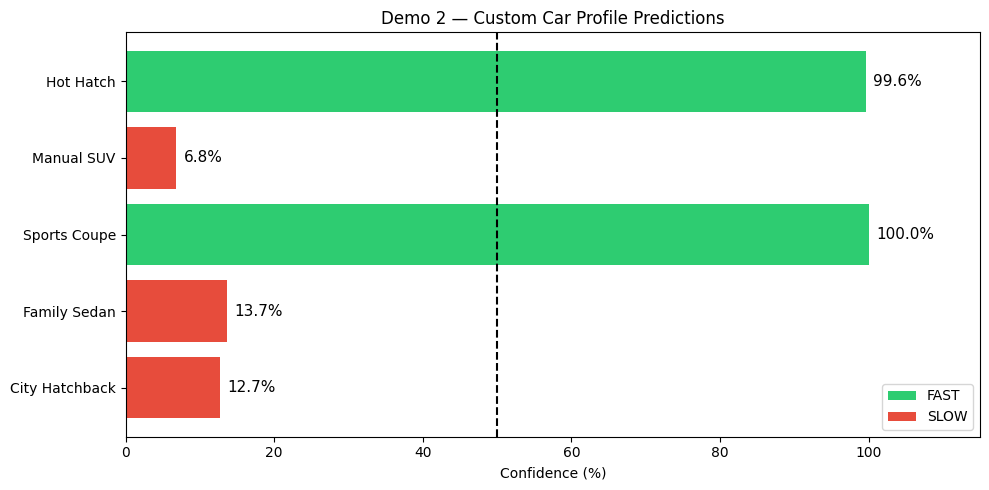

In [404]:
# DEMO 2: Visualization
conf_vals2 = [float(p.strip('%')) for p in demo_cars['Confidence']]
colors2 = ['#2ecc71' if p == 1 else '#e74c3c' for p in preds]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(demo_cars['name'], conf_vals2, color=colors2)
ax.axvline(x=50, color='black', linestyle='--', linewidth=1.5, label='50% threshold')

# Add confidence labels on bars
for bar, val in zip(bars, conf_vals2):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=11)

ax.set_xlabel('Confidence (%)')
ax.set_title('Demo 2 — Custom Car Profile Predictions')
ax.set_xlim(0, 115)
ax.legend()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='FAST'), Patch(facecolor='#e74c3c', label='SLOW')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()